In [1]:
pip install geopandas

Note: you may need to restart the kernel to use updated packages.


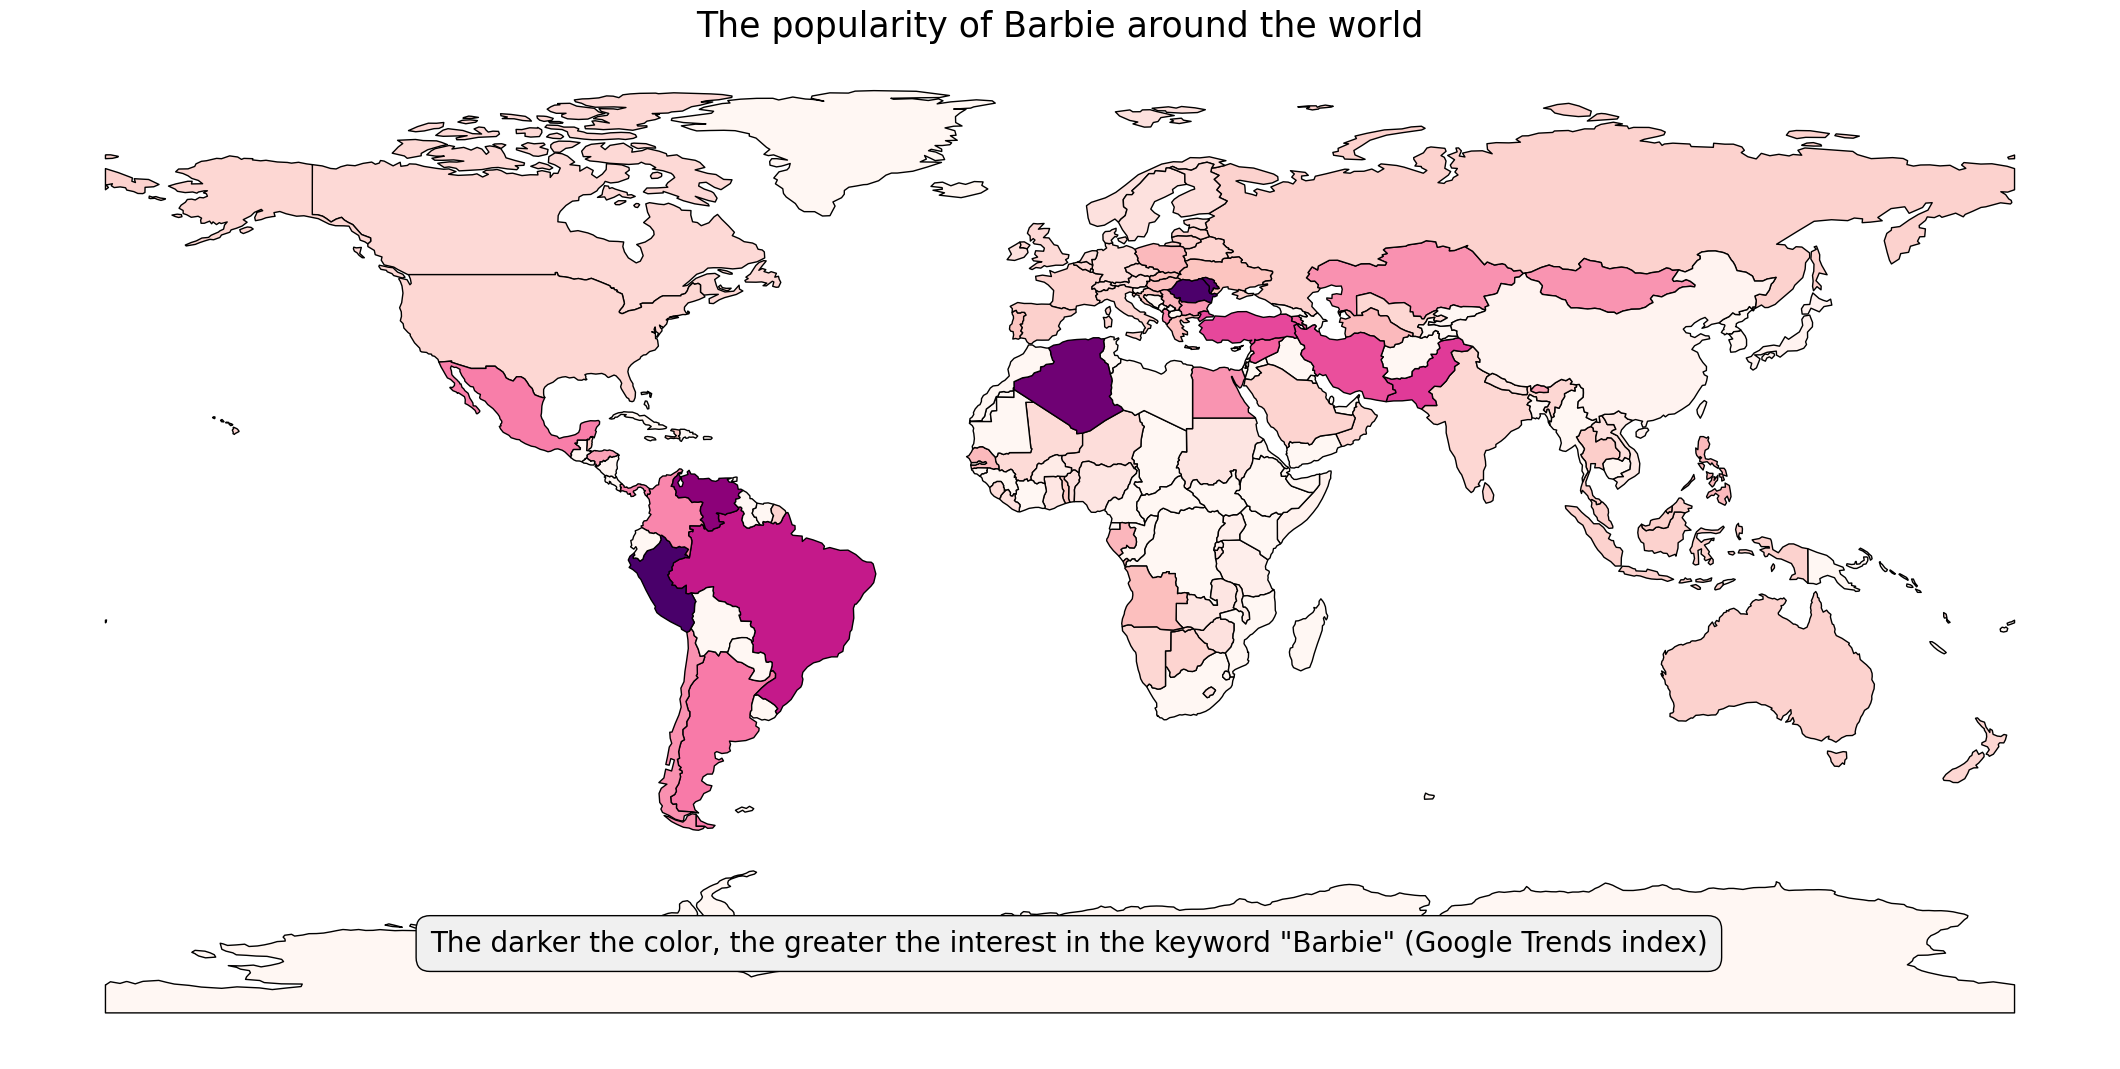

In [7]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/majazontek/Desktop/UCZELNIA/2 rok/wizualizacja danych/projekt/do wyslania do 23.12.25/pozostałe (do 10.01.2026)/barbie-kartogram1.csv', header=1)
df.columns = ['Kolumna1', 'Kolumna2']

df['Kolumna2'] = pd.to_numeric(df['Kolumna2'], errors='coerce').fillna(0)

pl_to_en = {
    'Stany Zjednoczone': 'United States of America', 'Wielka Brytania': 'United Kingdom',
    'Niemcy': 'Germany', 'Francja': 'France', 'Włochy': 'Italy', 'Hiszpania': 'Spain',
    'Polska': 'Poland', 'Rosja': 'Russia', 'Chiny': 'China', 'Indie': 'India',
    'Brazylia': 'Brazil', 'Kanada': 'Canada', 'Australia': 'Australia', 'Meksyk': 'Mexico',
    'Japonia': 'Japan', 'Turcja': 'Turkey', 'Egipt': 'Egypt', 'Indonezja': 'Indonesia',
    'Iran': 'Iran', 'Kolumbia': 'Colombia', 'Argentyna': 'Argentina', 'Ukraina': 'Ukraine',
    'Algieria': 'Algeria', 'Rumunia': 'Romania', 'Peru': 'Peru', 'Wenezuela': 'Venezuela',
    'Chile': 'Chile', 'Kazachstan': 'Kazakhstan', 'Arabia Saudyjska': 'Saudi Arabia',
    'Szwecja': 'Sweden', 'Norwegia': 'Norway', 'Finlandia': 'Finland', 'Grecja': 'Greece',
    'Holandia': 'Netherlands', 'Belgia': 'Belgium', 'Szwajcaria': 'Switzerland',
    'Austria': 'Austria', 'Czechy': 'Czechia', 'Węgry': 'Hungary',
    'Portugalia': 'Portugal', 'Dania': 'Denmark', 'Irlandia': 'Ireland',
    'RPA': 'South Africa', 'Południowa Afryka': 'South Africa', 'Nigeria': 'Nigeria',
    'Tajlandia': 'Thailand', 'Wietnam': 'Vietnam', 'Filipiny': 'Philippines',
    'Malezja': 'Malaysia', 'Nowa Zelandia': 'New Zealand', 'Pakistan': 'Pakistan',
    'Mołdawia': 'Moldova', 'Białoruś': 'Belarus', 'Litwa': 'Lithuania', 'Łotwa': 'Latvia',
    'Estonia': 'Estonia', 'Słowacja': 'Slovakia', 'Bułgaria': 'Bulgaria',
    'Chorwacja': 'Croatia', 'Serbia': 'Serbia'
}
df['Kolumna1'] = df['Kolumna1'].map(pl_to_en).fillna(df['Kolumna1'])

shapefile_url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(shapefile_url)

world = world.merge(df, left_on='NAME', right_on='Kolumna1', how='left')
world['Kolumna2'] = world['Kolumna2'].fillna(0)

fig, ax = plt.subplots(1, 1, figsize=(21.3, 12))

world.plot(column='Kolumna2',
           ax=ax,
           cmap='RdPu',
           edgecolor='black')

ax.text(0.2, 0.1,
        "The darker the color, the greater the interest in the keyword \"Barbie\" (Google Trends index)",
        transform=ax.transAxes,
        fontsize=20,
        verticalalignment='bottom',
        bbox=dict(facecolor='#f0f0f0', edgecolor='black', boxstyle='round,pad=0.5'))

plt.title("The popularity of Barbie around the world", fontsize=25)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('mapa-barbie.png')
plt.show()